# **Find M4 Phase Below (First sections are from previous phases)**

By: Allison Kramer

**Domain Question:** What underlying patterns emerge in how federal agencies structure and distribute grant funding?

**Problem Statement:**

This analysis explores underlying patterns in how federal agencies structure and distribute grant funding. Identifying these patterns can reveal whether agencies prioritize broad access, high-impact funding, or specialized initiatives. It can allow for insight into if they are favoring certain profiles over others - allowing for reflecton on if they should be investing more funding elsewhere. Its key to distinguish this question is comparing agencies and not individual opportunities.

While initial EDA provided a broad understanding of the dataset, additional targeted exploration was conducted to identify features most relevant for detecting agency-level funding strategy profiles.

## **EDA: Pre-Clustering Diagnostics** (Keeping what is neccessary for M4)

This exploratory analysis focuses on identifying whether federal agencies exhibit distinct funding strategy profiles based on funding scale, award volume, and reporting behavior.

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")

details = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv")

/tmp/ipython-input-2463505631.py:5: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")


In [88]:
print(f"Grants: ", grants.shape)
print(f"Details: ", details.shape)

Grants:  (74669, 17)
Details:  (2000, 68)


In [89]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

In [90]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

### **1. Missing Data Assessment**
Understanding missing data patterns is good when comparing agency strategies, as uneven reporting may distort funding comparisons.

In [91]:
# Examining whether funding data is missing systematically across agencies

# Missing Funding Rate by Agency (Top 15 Agencies by Volume)

top_agencies = grants['agency_name'].value_counts().head(15).index

missing_by_agency = (grants[grants['agency_name'].isin(top_agencies)]
                     .groupby('agency_name')['estimated_funding']
                     .apply(lambda s: s.isna().mean())
                     .sort_values(ascending=False))

missing_by_agency


,estimated_funding
agency_name,
NASA Headquarters,0.975355
National Institutes of Health,0.724353
Geological Survey,0.266551
Centers for Disease Control and Prevention,0.199189
Department of Commerce,0.141230
Department of Education,0.134831
National Science Foundation,0.057273
National Park Service,0.054237
Fish and Wildlife Service,0.038574


NASA Headquarters and National Institutes of Health has over a lot missing - it will effect comparability. NASA → ~97% missing & NIH → ~72% missing

### **2. Agency-Level Aggregation**
Constructing Agency Level Profiles

Because this research question focuses on agency strategy rather than individual opportunities, grant level data was aggregated to construct agency level summaries.


In [92]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

In [93]:
agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

agency_profile.sort_values('n_opps', ascending=False).head(10)

,agency_name,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
336,National Institutes of Health,11239,6.244770e+06,3000000.0,3924.891850,4.0,0.724353
338,National Park Service,8426,5.961203e+05,61000.0,186.935621,1.0,0.054237
209,Fish and Wildlife Service,4122,1.646400e+06,99000.0,166.960866,1.0,0.038574
78,Bureau of Land Management,2868,8.687874e+05,200000.0,776.749605,1.0,0.015690
221,Geological Survey,2311,4.645448e+05,75749.0,2.245690,1.0,0.266551
123,Centers for Disease Control and Prevention,1727,2.230190e+07,2122500.0,5682.843858,1.0,0.199189
233,Health Resources and Services Administration,1609,3.813759e+07,3070300.0,30.627488,8.0,0.005594
167,Department of Education,1513,9.723368e+07,3750000.0,8630.163985,8.0,0.134831
181,Dept. of the Army -- USAMRAA,1507,1.044582e+07,4800000.0,8.691739,4.0,0.013271
198,Environmental Protection Agency,1371,2.949487e+07,2000000.0,20.399113,8.0,0.001459


**Substantial variation emerges across agencies in both funding scale and award volume. Some agencies appear to distribute fewer, larger awards, while others fund a greater number of smaller opportunities. These early patterns provide preliminary evidence that agencies may operate under distinct funding strategies.**

**Because the research question is inherently agency-level, clustering will be performed on aggregated features rather than individual opportunities to ensure that inferred strategy profiles reflect institutional behavior rather than grant-level noise.**

### **3. Defining Features**

In [94]:
import numpy as np

features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Make sure features exists
print(features.shape)


(659, 4)


### **4. Preparing Data for Clustering - Log Transformation**



In [95]:
agency_profile.columns

Index(['agency_name', 'n_opps', 'avg_funding', 'med_funding', 'avg_awards',
       'med_awards', 'funding_missing_rate'],
      dtype='object')

In [96]:
import numpy as np

# Choosing my Features
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Create Log Features --> directly into dataframe
features.loc[:, 'log_n_opps'] = np.log1p(features['n_opps'])
features.loc[:, 'log_med_funding'] = np.log1p(features['med_funding'])
features.loc[:, 'log_med_awards'] = np.log1p(features['med_awards'])

# Final Feature Set Before Clustering
features = features[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']].copy()

## **Unsupervised Machine Learning (Original K-Means baseline)**

**To capture agency funding strategy, clustering was performed on four dimensions: opportunity volume (n_opps), typical funding level (med_funding), award size (med_awards), and reporting consistency (funding_missing_rate). Together, these variables approximate how aggressively and transparently agencies distribute federal funding.**

In [97]:
# KMeans cannot handle NaNs, rows with missing data will be removed for clustering
features.isna().sum().sort_values(ascending=False)
features_clean = features.dropna()

In [98]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

### **2. Determining the Optimal Number of Clusters**

**Find K - Elbow and Silhoutte**

**1. Elbow**

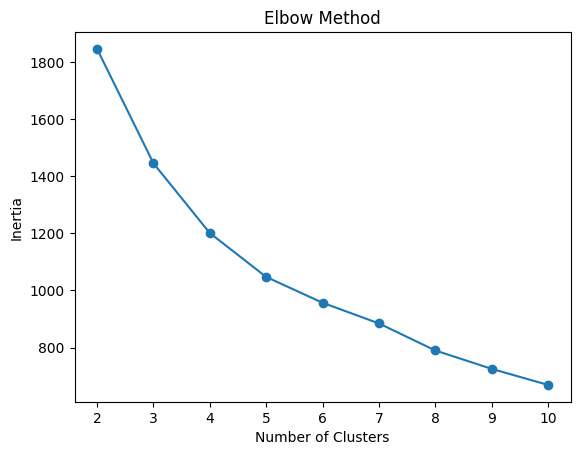

In [99]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

**The elbow begins forming around k=4, suggesting that 4 clusters likely capture the primary structure before marginal improvements diminish.**

**2. Silhoutte**

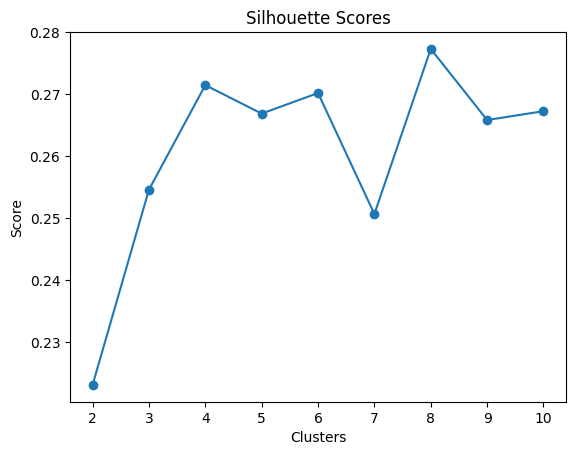

In [100]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,11), scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show()

**Although silhouette scores were slightly higher at larger k values, additional clusters created fragmented groups that were difficult to interpret strategically. A four cluster solution provided the best balance between statistical fit and practical interpretability.**

### **3. Fitting Model**

In [101]:
#Running K-Means & Picking 4 as my k

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Attatch Cluster Labels to Agencies
agency_profile_clean = agency_profile.loc[features_clean.index].copy()
agency_profile_clean['cluster'] = clusters


In [102]:
#Profile the Clusters

cluster_summary = agency_profile_clean.groupby('cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
cluster,,,,
0,7.0,225000.0,3.0,0.083333
1,24.0,3000000.0,1.0,0.583333
2,11.0,11250000.0,40.0,0.037037
3,145.5,1650000.0,2.0,0.116531


In [103]:
#Seeing if What Was Removed Would Impact Clustering

print("Original Amount:", len(features))
print("After dropna:", len(features_clean))

amount_removed = len(features) - len(features_clean)
print(f"Amount Removed: ", amount_removed)

pct_removed = 1 - (len(features_clean) / len(features))
print(f"Percent Removed: %", round(pct_removed, 4)*100)

Original Amount: 659
After dropna: 592
Amount Removed:  67
Percent Removed: % 10.17


**Approximately 10% of agencies were removed due to missing values. Because the majority of observations were retained, the risk of systematic bias in the clustering results is likely low.**

### **4. Visualizing the Clusters / Interpreting the Model**

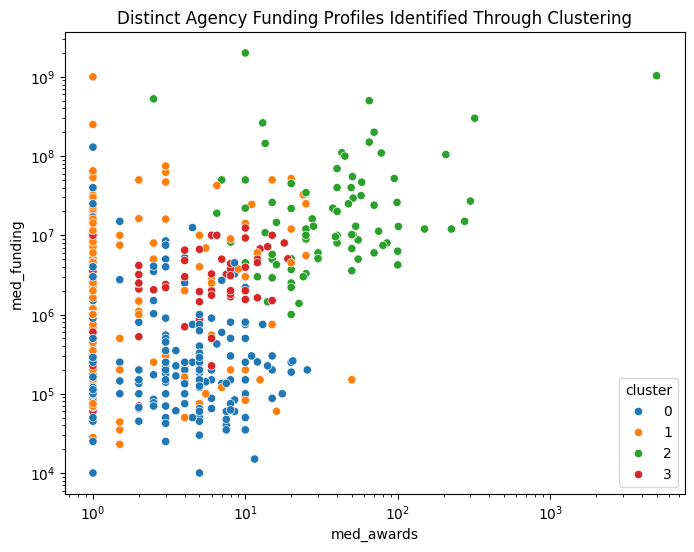

In [104]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agency_profile_clean,
    x='med_awards',
    y='med_funding',
    hue='cluster',
    palette='tab10'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Distinct Agency Funding Profiles Identified Through Clustering")
plt.show()


**Breif Interpretation:** **The Green Cluster:** mostly high funding along with higher awards, likely major funding agencies. **The Blue Cluster:** lower funding and lower awards, probably smaller agencies. **The Red Cluster:** mid range funding with not a huge counts, likely for possible specialized grants. **The Orange Cluster:** its pretty spread across funding levels, but it looks like lower awards so maybe inconsistent funding strategies for this cluster is present.

In [105]:
# Assign descriptive labels for interpretability
cluster_labels = {
    0: "Lower Funding / Smaller Awards",
    1: "Moderate Funding, Few Awards",
    2: "High Funding Agencies",
    3: "High Opportunity Agencies"}

agency_profile_clean['cluster_label'] = agency_profile_clean['cluster'].map(cluster_labels)

In [106]:
# Checking Table for Cluster Amount

cluster_profile = agency_profile_clean.groupby('cluster').agg({'n_opps':'median',
                                                               'med_funding':'median',
                                                               'med_awards':'median',
                                                               'funding_missing_rate':'median'})

cluster_profile['cluster_size'] = agency_profile_clean['cluster'].value_counts()

cluster_profile.sort_index()


,n_opps,med_funding,med_awards,funding_missing_rate,cluster_size
cluster,,,,,
0,7.0,225000.0,3.0,0.083333,235
1,24.0,3000000.0,1.0,0.583333,166
2,11.0,11250000.0,40.0,0.037037,91
3,145.5,1650000.0,2.0,0.116531,100


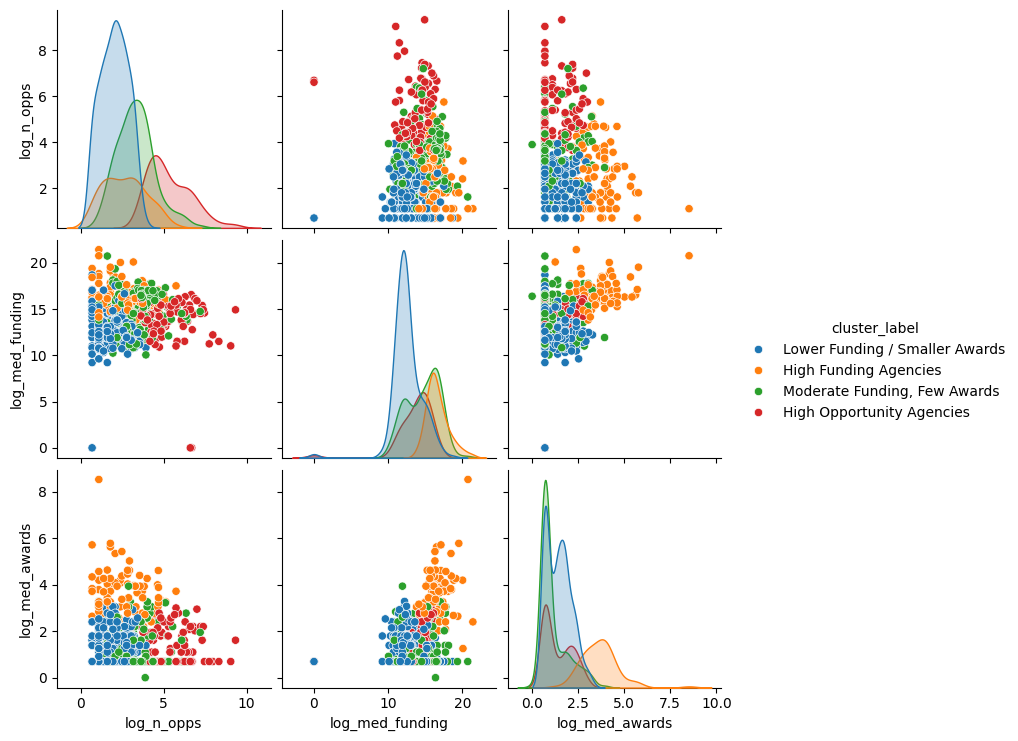

In [107]:
plot_df = features_clean.copy()
#plot_df['cluster'] = agency_profile_clean['cluster']
plot_df['cluster_label'] = agency_profile_clean['cluster_label']

sns.pairplot(
    plot_df,
    vars=['log_n_opps','log_med_funding','log_med_awards'],
    hue='cluster_label',
    palette='tab10'
)

plt.show()



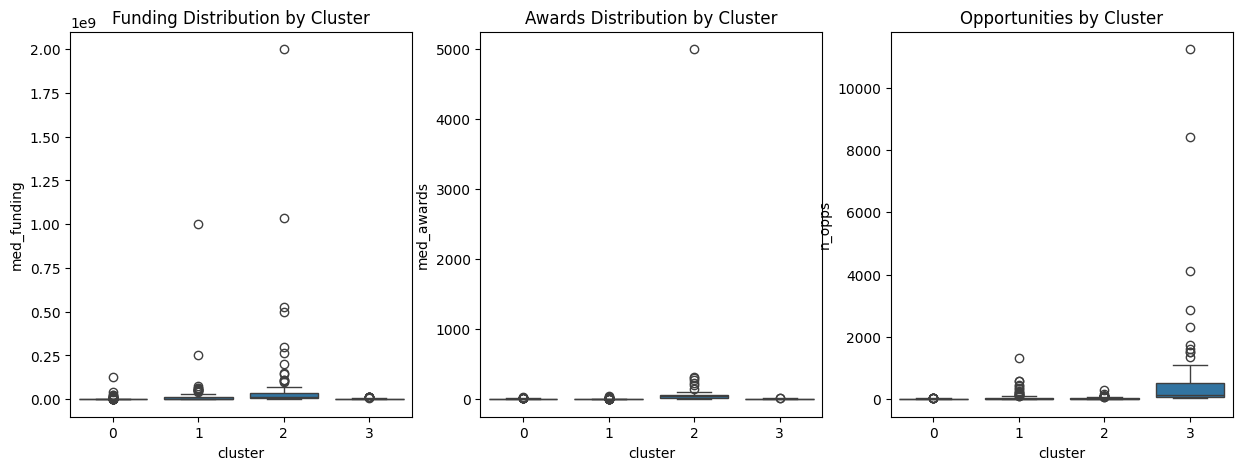

In [108]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_funding', ax=axes[0])
axes[0].set_title("Funding Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_awards', ax=axes[1])
axes[1].set_title("Awards Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='n_opps', ax=axes[2])
axes[2].set_title("Opportunities by Cluster")

plt.show()

**The clustering analysis reveals distinct agency funding strategies rather than perfectly separated groups. One cluster is characterized by substantially higher funding levels and award counts, indicating large scale funding institutions. Another cluster demonstrates high opportunity volume with more moderate funding levels, suggesting a strategy focused on distributing resources across many programs. Meanwhile, smaller clusters represent agencies with lower funding footprints, likely reflecting specialized or niche funding priorities. The presence of some overlap is expected in real-world financial data and reinforces that agency behaviors exist along a spectrum rather than within rigid boundaries.**

# **Integrations & Synergies (Kept Some as Baseline for M4)**

## **1) Seeing if Dropping or Filling N/A's Produce Better Insights**

### Preproccessing Experiment: (Sambisha, Maggies, Anna Decision)

**In M2, the elbow method was used to determine the optimal number of clusters (k=4). For M3 integration, I used silhouette scores as a baseline for preprocessing experimentation in order to compare whether dropping NAs or filling with zeros produced a better cluster structure. This told me which preprocessing decision was better rather than focusing on the choice of k, which remained consistent with M2 findings.**

In [109]:
# Importing everything again in case
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-inputing my agency profile code (what I did before above)
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

In [110]:
# FIRST OPTION
features_A = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

features_A['log_n_opps'] = np.log1p(features_A['n_opps'])
features_A['log_med_funding'] = np.log1p(features_A['med_funding'])
features_A['log_med_awards'] = np.log1p(features_A['med_awards'])

features_A = features_A[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']]

features_A_clean = features_A.dropna()

#^this is all same code from M2 - just renamed features variable for easier interpretation

In [111]:
#SECOND OPTION:

# Fill NAs with 0 (What Maggie, Sambisha, and Anna did)
features_B = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Fill BEFORE log transform
features_B['med_funding'] = features_B['med_funding'].fillna(0)
features_B['med_awards'] = features_B['med_awards'].fillna(0)

features_B['log_n_opps'] = np.log1p(features_B['n_opps'])
features_B['log_med_funding'] = np.log1p(features_B['med_funding'])
features_B['log_med_awards'] = np.log1p(features_B['med_awards'])

features_B = features_B[['log_n_opps', 'log_med_funding','log_med_awards', 'funding_missing_rate']]
features_B_clean = features_B.dropna()

In [112]:
# Seeing exactly how many is kept - tested in percent form before
print("Option A (Drop NAs) - agencies retained:", len(features_A_clean))
print("Option B (Fill 0s) - agencies retained:", len(features_B_clean))
print("Difference:", len(features_B_clean) - len(features_A_clean), "extra agencies")

Option A (Drop NAs) - agencies retained: 592
Option B (Fill 0s) - agencies retained: 659
Difference: 67 extra agencies


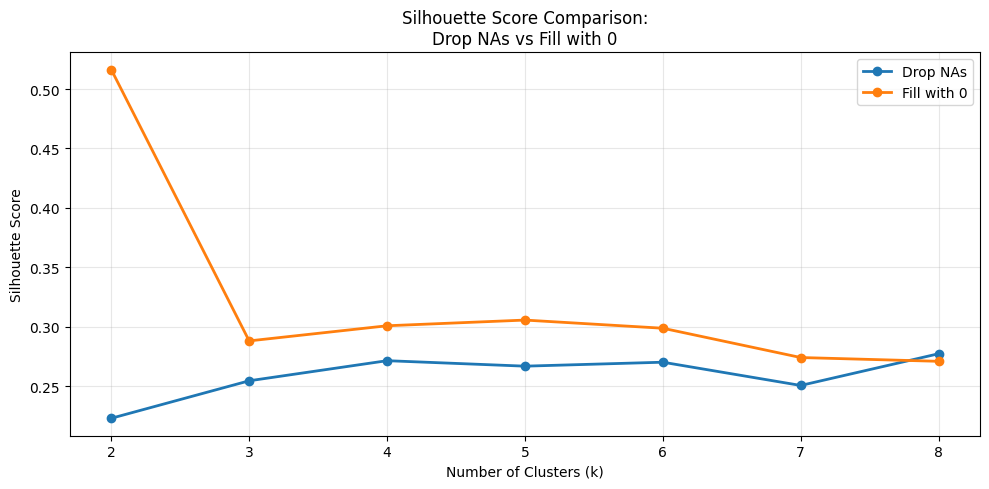


Best silhouette scores:
    k       method  silhouette  n_agencies
12  8     Drop NAs    0.277336         592
1   2  Fill with 0    0.516377         659


In [113]:
# Compare Silhouette Scores Across k for BOTH options
results = []

for k in range(2, 9):
    for name, features in [("Drop NAs", features_A_clean),
                            ("Fill with 0", features_B_clean)]:
        scaler = StandardScaler()
        X = scaler.fit_transform(features)
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        results.append({'k': k, 'method': name, 'silhouette': score,'n_agencies': len(features)})

results_df = pd.DataFrame(results)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))

for method, group in results_df.groupby('method'):
    ax.plot(group['k'], group['silhouette'],
            marker='o', label=method, linewidth=2)

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score Comparison:\nDrop NAs vs Fill with 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest silhouette scores:")
print(results_df.loc[results_df.groupby('method')['silhouette'].idxmax()])

# **M4 Phase: Refinement & Deeper Experimentation**

## **What Changed Since M3 Submission:**
**1. Robustness Analysis** - Tested K-Means stability across 10 random seeds and compared k=3, 4, 5 cluster solutions with silhouette scores and membership stability metrics

**2. Alternative Clustering Method** - Applied Agglomerative (Hierarchical) Clustering with dendrogram visualization to reveal agency relationship structure without pre-specifying k

**3. PCA Exploration** — Examined whether dimensionality reduction before clustering improves or changes results (feature engineering step from class)

**4. Method Comparison** — Compared K-Means vs. Hierarchical clustering side-by-side on silhouette scores, cluster sizes, and membership overlap

**5. Updated Business Insights** — Sharper, more specific recommendations tied to refined analysis

## **1. Robustness Analysis**

**1 a. Seed Stability Test (k = 4, 10 random seeds)**

In [114]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Need to run K-Means 10 times with diff random seeds --> see if clusters are stable
seeds = [0, 7, 13, 21, 42, 55, 77, 99, 123, 256]
results = []

for s in seeds:
    km = KMeans(n_clusters=4, random_state=s, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({'seed': s, 'silhouette': round(sil, 4)})

results_df = pd.DataFrame(results)
print("Silhouette Scores Across 10 Random Seeds (k=4):")
print(results_df.to_string(index=False))
print(f"Mean Silhouette: {results_df['silhouette'].mean():.4f}")
print(f"Std Dev:{results_df['silhouette'].std():.4f}")

#I want to organize results to tell me if stable
if results_df['silhouette'].std() < 0.01:
    print("\n--> Very low variance across seeds. The clusters are STABLE.")
else:
    print("\n--> Some variation across seeds. Clusters may be somewhat sensitive to initialization.")

Silhouette Scores Across 10 Random Seeds (k=4):
 seed  silhouette
    0      0.2715
    7      0.2715
   13      0.2717
   21      0.2733
   42      0.2715
   55      0.2717
   77      0.2715
   99      0.2715
  123      0.2733
  256      0.2740
Mean Silhouette: 0.2722
Std Dev:0.0010

--> Very low variance across seeds. The clusters are STABLE.


**The standard deviation across seeds is only 0.0010, and all silhouette scores are between 0.271 and 0.274. This means the clusters are extremely stable. K-Means finds the same structure no matter where it starts. This gives us strong evidence that the 4 agency profiles are real patterns in the data.**

In [115]:
# I want to check if two different seeds produce the same cluster assignments...

# Comparing seed=42 vs seed=0

km_42 = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
km_0  = KMeans(n_clusters=4, random_state=0, n_init=10).fit_predict(X_scaled)

from sklearn.metrics import adjusted_rand_score
adusted_score = adjusted_rand_score(km_42, km_0)

print(f"Agreement between seed=42 and seed=0: {adusted_score:.4f}")
print(f"(1.0 = same clusters, 0.0 = completely different)")

if adusted_score > 0.9:
    print("\n--> Produced the SAME clusters.")
elif adusted_score > 0.7:
    print("\n--> Mostly the same, a few agencies shifted between clusters.")
else:
    print("\n--> Big differences")

Agreement between seed=42 and seed=0: 1.0000
(1.0 = same clusters, 0.0 = completely different)

--> Produced the SAME clusters.


**1 b. Comparing k=3, 4, 5 Solutions**

In [116]:
# Compare the silhouette scores
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k} → Silhouette: {sil:.4f}, Cluster sizes: {np.bincount(labels)}")

k=3 → Silhouette: 0.2546, Cluster sizes: [262 109 221]
k=4 → Silhouette: 0.2715, Cluster sizes: [235 166  91 100]
k=5 → Silhouette: 0.2669, Cluster sizes: [124 174 119 104  71]


## **2. Alternative Clustering Method: Agglomerative (Hierarchical) Clustering**

K-Means requires pre-specifying k and assumes spherical clusters. Agglomerative clustering offers a different perspective:
- **Do not need to pre-specify k** because the dendrogram reveals natural groupings
- **Shows relationships** between clusters (which agency types are most similar)
- **Different distance metrics** can be explored (Ward, complete, average linkage)

This serves as the "method upgrade" for M4 — testing whether a different algorithm discovers the same or different agency funding profiles.

**Hierarchical clustering is well suited for this analysis because it reveals how agency funding profiles relate to each other and not just which group each agency belongs to, but which groups are most similar. This is valuable for understanding the federal grant landscape, where agency strategies may exist on a wide spectrum rather than as noticable distinct types or categories.**

**2 a. Creating Dendrogram**

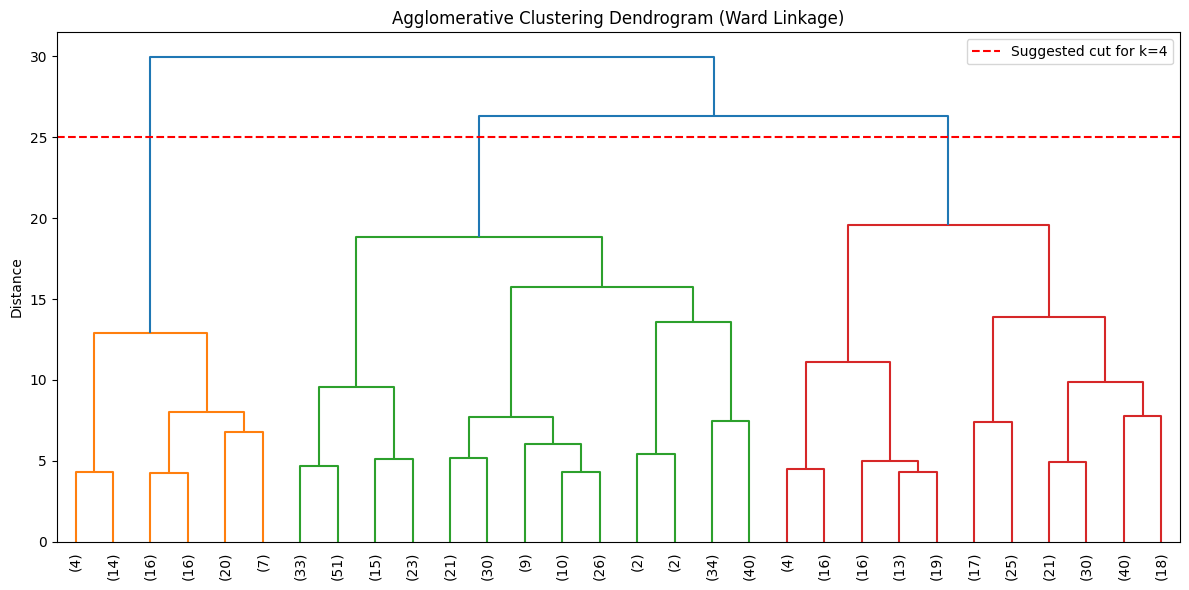

In [117]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

# Using Ward linkage to minimize within cluster variance
Z = linkage(X_scaled, 'ward')

#plot
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title("Agglomerative Clustering Dendrogram (Ward Linkage)")
plt.ylabel("Distance")
plt.axhline(y=25, color='r', linestyle='--', label='Suggested cut for k=4')
plt.legend()
plt.tight_layout()
plt.show()

**2 b. Fitting k=4 to hierachical clustering to compare with kmeans**

In [118]:
# Fit Agglomerative Clustering with k=4 (same as K-Means for comparison)
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agency_profile_clean['agg_cluster'] = agg.fit_predict(X_scaled)

# Profile the clusters
print("Hierarchical Cluster Profiles:")
print(agency_profile_clean.groupby('agg_cluster')[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].median())

Hierarchical Cluster Profiles:
             n_opps  med_funding  med_awards  funding_missing_rate
agg_cluster                                                       
0               9.0     200000.0         2.5              0.169048
1              10.0   14550000.0        47.5              0.092593
2              32.0    6000000.0         1.0              0.454545
3             110.0    3725000.0         9.5              0.055755


**The hierarchical cluster profiles reveal a different grouping structure than K-Means. Cluster 1 stands out with very high median funding ($14.5M) and high awards (47.5), while Cluster 3 has the highest opportunity volume (110). Cluster 2 is interesting as moderate funding but a very high missing rate (0.45), suggesting agencies that may not consistently report funding. This "high-missing-rate" group wasn't as clearly separated in K-Means.**

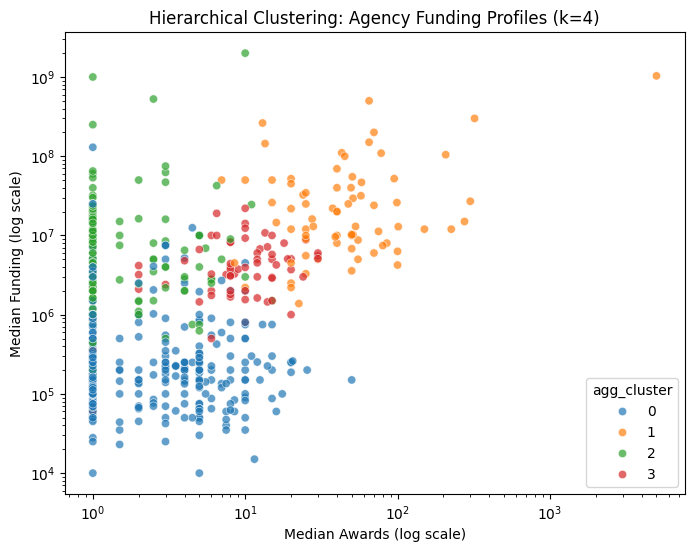

In [119]:
# Visualizing hierarchical clusters same way as K-Means
plt.figure(figsize=(8, 6))

sns.scatterplot(data=agency_profile_clean, x='med_awards', y='med_funding', hue='agg_cluster', palette='tab10', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Median Awards (log scale)")
plt.ylabel("Median Funding (log scale)")

plt.title("Hierarchical Clustering: Agency Funding Profiles (k=4)")
plt.show()

**2 c. Comparing methods**

In [120]:
# Compare different linkage methods
from sklearn.metrics import silhouette_score

for method in ['ward', 'complete', 'average']:
    agg_temp = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = agg_temp.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"{method:>10} linkage → Silhouette: {sil:.4f}")

      ward linkage → Silhouette: 0.2186
  complete linkage → Silhouette: 0.1402
   average linkage → Silhouette: 0.4120


## **3. PCA Exploration - Does dimensionality reduction help?**

In [121]:
# check if there is redundancy
from sklearn.decomposition import PCA

model = PCA()
model.fit(X_scaled)

# Explained variance (asked for help here on how to represent this)
print("Explained variance per component:")

for i, var in enumerate(model.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"Total with 2 PCs: {sum(model.explained_variance_ratio_[:2])*100:.1f}%")

Explained variance per component:
  PC1: 0.347 (34.7%)
  PC2: 0.298 (29.8%)
  PC3: 0.214 (21.4%)
  PC4: 0.142 (14.2%)
Total with 2 PCs: 64.5%


**PCA reveals that no single component dominates... PC1 explains only 34.7% and PC2 explains 29.8%. This means all four features contribute meaningfully to the clustering, and there's no major redundancy to compress. Also, the variance is pretty spread across all 4 components, which is different from datasets where 2 PCs capture 90% plus of variance.**

In [122]:
# Does clustering on PCs change results?
X_pca_2 = PCA(n_components=2).fit_transform(X_scaled)

km_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_pca_2)

km_orig = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_orig = km_orig.fit_predict(X_scaled)

print(f"Silhouette on 2 PCs: {silhouette_score(X_pca_2, labels_pca):.4f}")
print(f"Silhouette on original 4 features: {silhouette_score(X_scaled, labels_orig):.4f}")

Silhouette on 2 PCs: 0.3792
Silhouette on original 4 features: 0.2715


## **4. Method Comparison: K-Means vs. Hierarchical Clustering**

In [123]:
# Comparing kmeans and hierarchical

from sklearn.metrics import adjusted_rand_score

kmeans_sil = silhouette_score(X_scaled, agency_profile_clean['cluster'].values)
agg_sil = silhouette_score(X_scaled, agency_profile_clean['agg_cluster'].values)
adjusted_score = adjusted_rand_score(agency_profile_clean['cluster'].values,
                                     agency_profile_clean['agg_cluster'].values)

print("K-Means vs Hierarchical Comparison:")
print(f"K-Means Silhouette: {kmeans_sil:.4f}")
print(f"Hierarchical Silhouette: {agg_sil:.4f}")
print(f"Agreement (adjusted_score): {adjusted_score:.4f}  (1.0 = identical clusters)")

K-Means vs Hierarchical Comparison:
K-Means Silhouette: 0.2715
Hierarchical Silhouette: 0.2186
Agreement (adjusted_score): 0.4173  (1.0 = identical clusters)


**The adjusted score of 0.42 indicates moderate agreement. It seems that the two methods are finding overlapping but not identical structures. K-Means slightly outperforms on silhouette (0.27 vs 0.22 with Ward linkage), which makes sense since K-Means directly optimizes for compact and well separated clusters. The fact that the methods partially disagree is actually interesting and tells a story: it means some agencies sit on the boundary between profiles, and their classification depends on the algorithm's assumptions.**

In [124]:
# Cross-tabulation: How do K-Means clusters map to Hierarchical clusters?

cross_tab = pd.crosstab(
    agency_profile_clean['cluster_label'],
    agency_profile_clean['agg_cluster'],
    margins=True)

print("Cross-tabulation: K-Means Labels vs Hierarchical Clusters \n")
print(cross_tab)

Cross-tabulation: K-Means Labels vs Hierarchical Clusters 

agg_cluster                       0   1    2   3  All
cluster_label                                        
High Funding Agencies             1  68    2  20   91
High Opportunity Agencies        40   0   16  44  100
Lower Funding / Smaller Awards  208   2   24   1  235
Moderate Funding, Few Awards     47   7  109   3  166
All                             296  77  151  68  592


**The cross-tabulation shows how agencies are classified differently between the two methods.**

**For example, most "Lower Funding / Smaller Awards" agencies (208 out of 235) land in Hierarchical Cluster 0, meaning the methods mostly agree on that group. However, "High Opportunity Agencies" are split across Hierarchical Clusters 0, 2, and 3, suggesting that hierarchical clustering is subdividing what K-Means treats as a single group. This tells us the "High Opportunity" profile may contain sub-types that K-Means is merging together.**

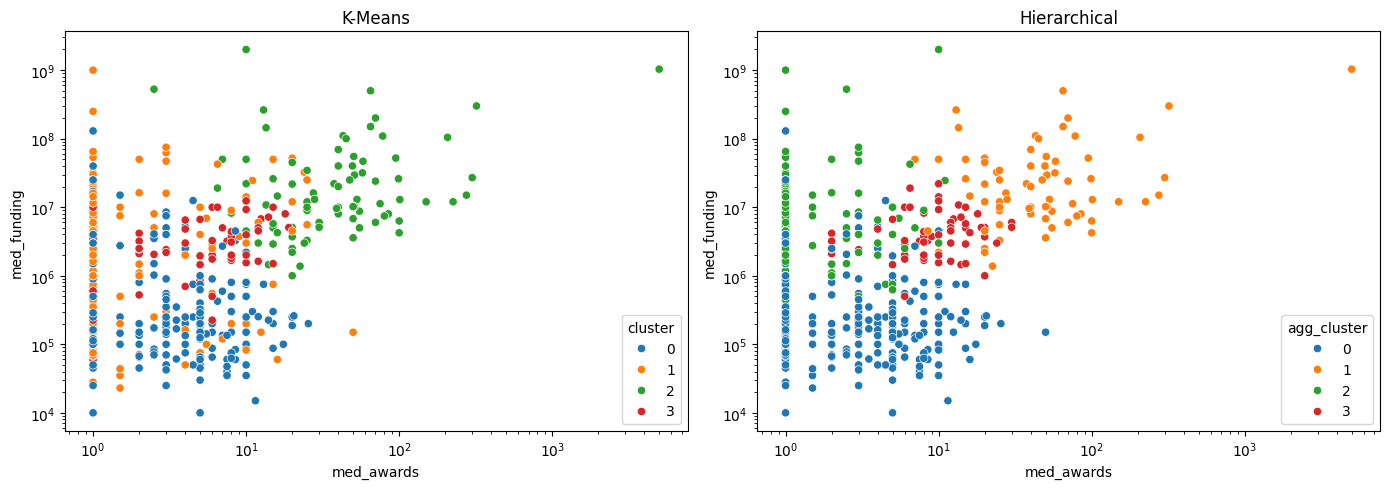

In [125]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: K-Means
sns.scatterplot(data=agency_profile_clean, x='med_awards', y='med_funding',
                hue='cluster', palette='tab10', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('K-Means')

# Right plot: Hierarchical
sns.scatterplot(data=agency_profile_clean, x='med_awards', y='med_funding',
                hue='agg_cluster', palette='tab10', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Hierarchical')

plt.tight_layout()
plt.show()

## **5. Updated Findings / Business Insights**

**Domain Question:** What underlying patterns emerge in how federal agencies structure and distribute grant funding?

### **Key Findings from M4 Phase:**

**1. The 4 agency funding profiles are robust and stable.**

Seed stability testing showed a standard deviation of only 0.0010 across 10 random initializations, and seed=42 vs seed=0 produced a perfect adjusted score of 1.0. This means the profiles (High Funding, High Opportunity, Moderate Funding, and Lower Funding) are genuine structural patterns, not just results from K-Means initialization.

**2. k=4 is the strongest solution.**

By comparing k=3, 4, and 5, k=4, we achieved the highest silhouette score (0.272) with balanced cluster sizes. k=3 merges distinct groups, and k=5 fragments them without adding any more value.

**3. Hierarchical clustering somewhat validates and extends the K-Means findings.**

With Ward linkage, the adjusted score between the two methods was 0.42 (moderate agreement). The biggest difference is that hierarchical clustering splits the "High Opportunity" group into sub-types and identifies a distinct cluster of agencies with high funding missing rates. This suggests some agency profiles have internal differences that K-Means smooths over.

**4. Average linkage outperformed Ward for hierarchical clustering**

(silhouette 0.41 vs 0.22), which was an unexpected finding. This suggests the agency clusters may not have equal variance with some profiles being tighter than others.

**5. PCA shows all 4 features matter.**

No single principal component dominates (PC1 = 34.7%), meaning opportunity volume, funding level, award size, and reporting consistency each contribute unique information. Interestingly, clustering on just 2 PCs actually produced a higher silhouette (0.38 vs 0.27), suggesting that compressing the features removes some noise and improves cluster separation.

**What are the Business Applications?**

Federal grant applicants should tailor their strategy based on agency profile: (Possible Implications)

- **High Opportunity Agencies:** High volume, broad eligibility → submit more applications, cast a wide net
- **High Funding Agencies:** Fewer but much larger awards → invest more in each proposal, target specific RFPs
- **Moderate Funding / Few Awards**: Niche agencies with selective funding → highly specialized proposals needed
- **Lower Funding / Smaller Awards**: Smaller agencies, often restricted eligibility → best for targeted local/regional applicants

The stability of these profiles across methods and random seeds means this guidance is reliable, not dependent on which analytical approach or choice we make.